In [3]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from utils import plot_learning_curve, plot_roc
from sklearn.model_selection import StratifiedKFold


# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()
# -------------------------------


# Load Data
# -------------------------------
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')
test_ids = X_test['PassengerId']
X_test.drop(columns=['PassengerId'], inplace=True)

# Flatten target if needed
# Map target to numeric
target = 'Survived'

y_train_numeric = y_train[target]


num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 2
X_train shape: (891, 13)
X_test shape: (418, 13)


In [7]:
def plot_learning_curve(estimator, title, X, y, cv,
                        train_sizes=np.linspace(0.1, 1.0, 5),
                        scoring='accuracy'):
    """
    General learning curve plot for any scikit-learn estimator.
    Handles nested estimators safely (e.g., AdaBoost, GradientBoosting, Stacking).
    
    Parameters
    ----------
    estimator : scikit-learn estimator
        Any classifier/regressor with fit() method.
    title : str
        Title of the plot.
    X : array-like or DataFrame
        Feature matrix.
    y : array-like or Series
        Target values.
    cv : cross-validation splitter
        e.g., StratifiedKFold or KFold instance.
    train_sizes : array-like
        Fractions of training data to use.
    scoring : str
        'accuracy', 'roc_auc', or 'log_loss'.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

    train_scores_mean, train_scores_std = [], []
    cv_scores_mean, cv_scores_std = [], []

    # Separate base estimator if exists (like AdaBoost)
    base_estimator = getattr(estimator, "estimator", None)
    if base_estimator is not None:
        base_params = base_estimator.get_params()
        # Keep only top-level params for the wrapper estimator
        wrapper_params = {k: v for k, v in estimator.get_params().items() if not k.startswith("estimator__") and k != "estimator"}
    else:
        wrapper_params = estimator.get_params()
        base_params = None

    for frac in train_sizes:
        train_fold_scores, cv_fold_scores = [], []

        for train_idx, test_idx in cv.split(X, y):
            n_train = max(1, int(len(train_idx) * frac))
            train_subset_idx = train_idx[:n_train]

            X_train_subset = X.iloc[train_subset_idx] if hasattr(X, "iloc") else X[train_subset_idx]
            y_train_subset = y.iloc[train_subset_idx] if hasattr(y, "iloc") else y[train_subset_idx]
            X_test_fold = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]
            y_test_fold = y.iloc[test_idx] if hasattr(y, "iloc") else y[test_idx]

            # Recreate estimator safely
            if base_estimator is not None:
                # Nested estimator
                est = estimator.__class__(estimator=base_estimator.__class__(**base_params), **wrapper_params)
            else:
                est = estimator.__class__(**wrapper_params)

            est.fit(X_train_subset, y_train_subset)

            # Make predictions
            if hasattr(est, "predict_proba"):
                y_train_pred = est.predict_proba(X_train_subset)[:, 1]
                y_test_pred = est.predict_proba(X_test_fold)[:, 1]
            else:
                y_train_pred = est.predict(X_train_subset)
                y_test_pred = est.predict(X_test_fold)

            # Compute score
            if scoring == 'accuracy':
                train_fold_scores.append(accuracy_score(y_train_subset, (y_train_pred >= 0.5).astype(int)))
                cv_fold_scores.append(accuracy_score(y_test_fold, (y_test_pred >= 0.5).astype(int)))
            elif scoring == 'roc_auc':
                train_fold_scores.append(roc_auc_score(y_train_subset, y_train_pred))
                cv_fold_scores.append(roc_auc_score(y_test_fold, y_test_pred))
            elif scoring == 'log_loss':
                train_fold_scores.append(-log_loss(y_train_subset, y_train_pred))
                cv_fold_scores.append(-log_loss(y_test_fold, y_test_pred))
            else:
                raise ValueError(f"Unsupported scoring: {scoring}")

        train_scores_mean.append(np.mean(train_fold_scores))
        train_scores_std.append(np.std(train_fold_scores))
        cv_scores_mean.append(np.mean(cv_fold_scores))
        cv_scores_std.append(np.std(cv_fold_scores))

    # Plot
    plt.figure(figsize=(8,6))
    plt.title(title)
    plt.xlabel("Training set fraction")
    plt.ylabel(scoring)
    plt.grid(True)

    plt.fill_between(train_sizes,
                     np.array(train_scores_mean) - np.array(train_scores_std),
                     np.array(train_scores_mean) + np.array(train_scores_std),
                     alpha=0.1, color='r')
    plt.fill_between(train_sizes,
                     np.array(cv_scores_mean) - np.array(cv_scores_std),
                     np.array(cv_scores_mean) + np.array(cv_scores_std),
                     alpha=0.1, color='g')
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, cv_scores_mean, 'o-', color='g', label='CV score')
    plt.legend(loc='best')
    plt.show()


[I 2026-02-10 00:48:04,381] A new study created in memory with name: no-name-cbf51ad3-10a1-45dc-a06a-28fcd7b64169
[I 2026-02-10 00:48:05,395] Trial 0 finished with value: 0.5673294846147715 and parameters: {'n_estimators': 218, 'learning_rate': 0.7969454818643931, 'algorithm': 'SAMME', 'max_depth': 1, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 0 with value: 0.5673294846147715.
[I 2026-02-10 00:48:07,208] Trial 1 finished with value: 0.42938906400186294 and parameters: {'n_estimators': 369, 'learning_rate': 0.010994335574766204, 'algorithm': 'SAMME', 'max_depth': 2, 'min_samples_split': 5, 'min_samples_leaf': 2, 'criterion': 'entropy'}. Best is trial 1 with value: 0.42938906400186294.
[I 2026-02-10 00:48:08,394] Trial 2 finished with value: 0.4407345924876755 and parameters: {'n_estimators': 244, 'learning_rate': 0.038234752246751866, 'algorithm': 'SAMME', 'max_depth': 2, 'min_samples_split': 8, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is

Optuna finished in 58.02 seconds
Best params: {'n_estimators': 212, 'learning_rate': 0.010424344986262718, 'algorithm': 'SAMME', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 7, 'criterion': 'entropy'}
Best CV log_loss: 0.40599927516411716
Train ROC AUC: 0.91101
Train Log Loss: 0.36412
Train Accuracy: 0.85522


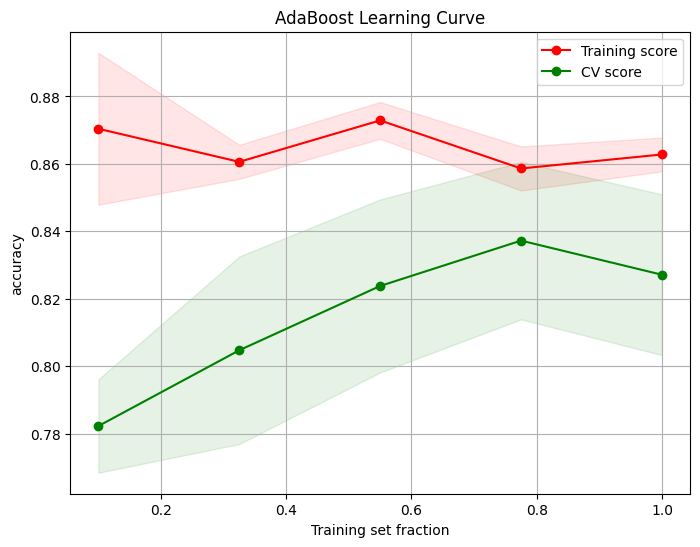

CV ROC-AUC: 0.8785547383547103
CV Log Loss: 0.40599927516411716
CV Accuracy: 0.8271357730211537


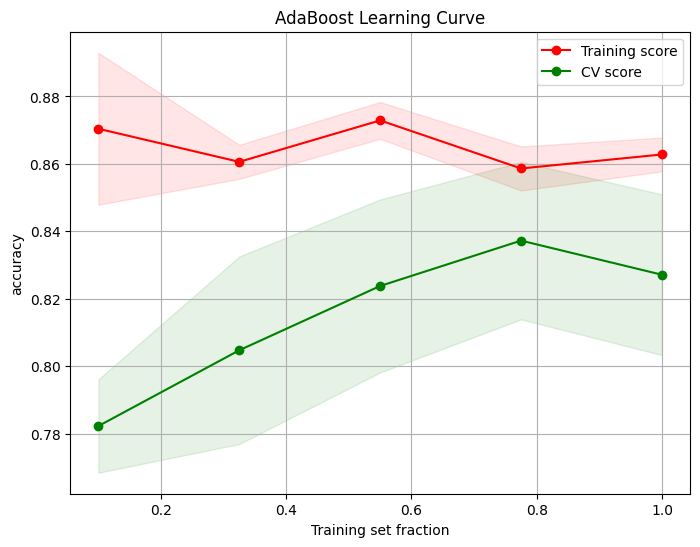

Submission saved!


7750

In [ ]:
import optuna
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd
import time
import gc

# -------------------------------
# Optuna objective function for AdaBoost
# -------------------------------
def objective(trial):
    # Sample hyperparameters for AdaBoost
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
    algorithm = trial.suggest_categorical("algorithm", ["SAMME", "SAMME.R"])
    
    # Sample hyperparameters for base DecisionTreeClassifier
    max_depth = trial.suggest_int("max_depth", 1, 5)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    
    base_estimator = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion
    )
    
    model = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        algorithm=algorithm,
        random_state=42
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    logloss_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train_numeric)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

        model.fit(X_tr, y_tr)
        pred_val = model.predict_proba(X_val)[:, 1]  # probabilities for binary log_loss
        fold_logloss = log_loss(y_val, pred_val)
        logloss_scores.append(fold_logloss)

        # Optional pruning
        trial.report(fold_logloss, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(logloss_scores)

# -------------------------------
# Optuna study setup
# -------------------------------
start = time.time()

sampler = optuna.samplers.TPESampler(
    n_startup_trials=20,
    multivariate=True,
    seed=42
)

pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2,
    reduction_factor=4,
    min_early_stopping_rate=1
)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    pruner=pruner
)

study.optimize(objective, n_trials=50, timeout=3600)  # adjust trials/time as needed

end = time.time()
print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV log_loss:", study.best_value)

# -------------------------------
# Train final AdaBoost model with best params
# -------------------------------
best_params = study.best_params

final_base_estimator = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    criterion=best_params['criterion']
)

final_model = AdaBoostClassifier(
    estimator=final_base_estimator,
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    algorithm=best_params['algorithm'],
    random_state=42
)

final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on training set
# -------------------------------
pred_train_proba = final_model.predict_proba(X_train)[:, 1]
pred_train_class = (pred_train_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_train_numeric, pred_train_proba)
logloss = log_loss(y_train_numeric, pred_train_proba)
accuracy = accuracy_score(y_train_numeric, pred_train_class)

print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")



# -------------------------------
# Evaluate on CV set
# -------------------------------

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='roc_auc')
logloss_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='neg_log_loss')
accuracy_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='accuracy')

print("CV ROC-AUC:", np.mean(roc_auc_scores))
print("CV Log Loss:", -np.mean(logloss_scores))
print("CV Accuracy:", np.mean(accuracy_scores))


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
plot_learning_curve(
    final_model,
    title="AdaBoost Learning Curve",
    X=X_train,
    y=y_train_numeric,
    cv=kfold,
    scoring='accuracy'  # or 'roc_auc' if you want ROC-AUC
)
# roc_auc_train = plot_roc(y_train_numeric, pred_train_proba, label='Bagged Tree Train')

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test_proba = final_model.predict_proba(X_test)[:, 1]
pred_test_class = (pred_test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_ids,  # replace with your test IDs
    "Survived": pred_test_class
})

submission.to_csv("submission/adaboost_optuna_submission.csv", index=False)
print("Submission saved!")
gc.collect()


# BaggingClassifier

In [ ]:
import optuna
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd
import time
import gc

# -------------------------------
# Optuna objective function for BaggingClassifier
# -------------------------------
def objective(trial):
    # Sample hyperparameters for BaggingClassifier
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_samples = trial.suggest_float("max_samples", 0.5, 1.0)
    max_features = trial.suggest_float("max_features", 0.5, 1.0)
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])

    # Sample hyperparameters for base DecisionTreeClassifier
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    base_estimator = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )

    model = BaggingClassifier(
        estimator=base_estimator,
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        bootstrap=bootstrap,
        n_jobs=-1,
        random_state=42
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    logloss_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train_numeric)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

        model.fit(X_tr, y_tr)
        pred_val = model.predict_proba(X_val)[:, 1]  # probabilities for log_loss
        fold_logloss = log_loss(y_val, pred_val)
        logloss_scores.append(fold_logloss)

        # Optional pruning
        trial.report(fold_logloss, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(logloss_scores)

# -------------------------------
# Optuna study setup
# -------------------------------
start = time.time()

sampler = optuna.samplers.TPESampler(
    n_startup_trials=20,
    multivariate=True,
    seed=42
)

pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2,
    reduction_factor=4,
    min_early_stopping_rate=1
)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    pruner=pruner
)

study.optimize(objective, n_trials=50, timeout=3600)  # adjust as needed

end = time.time()
print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV log_loss:", study.best_value)

# -------------------------------
# Train final Bagging model with best params
# -------------------------------
best_params = study.best_params

final_base_estimator = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    criterion=best_params['criterion'],
    random_state=42
)

final_model = BaggingClassifier(
    estimator=final_base_estimator,
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    bootstrap=best_params['bootstrap'],
    n_jobs=-1,
    random_state=42
)

final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on training set
# -------------------------------
pred_train_proba = final_model.predict_proba(X_train)[:, 1]
pred_train_class = (pred_train_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_train_numeric, pred_train_proba)
logloss = log_loss(y_train_numeric, pred_train_proba)
accuracy = accuracy_score(y_train_numeric, pred_train_class)

print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")


# -------------------------------
# Evaluate on CV set
# -------------------------------

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='roc_auc')
logloss_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='neg_log_loss')
accuracy_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='accuracy')

print("CV ROC-AUC:", np.mean(roc_auc_scores))
print("CV Log Loss:", -np.mean(logloss_scores))
print("CV Accuracy:", np.mean(accuracy_scores))


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

plot_learning_curve(
    estimator=final_model,
    title="BaggingClassifier Learning Curve",
    X=X_train,
    y=y_train_numeric,
    cv=skf,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'   # or 'roc_auc', 'log_loss'
)
# roc_auc_train = plot_roc(y_train_numeric, pred_train_proba, label='Bagged Tree Train')


# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test_proba = final_model.predict_proba(X_test)[:, 1]
pred_test_class = (pred_test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_ids,  # replace with your test IDs
    "Survived": pred_test_class
})

submission.to_csv("submission/baggedtree_optuna_submission.csv", index=False)
print("Submission saved!")
gc.collect()


[I 2026-02-10 00:49:18,049] A new study created in memory with name: no-name-70d0aef4-c229-4d79-b860-5f0537b6c613
[I 2026-02-10 00:49:19,798] Trial 0 finished with value: 0.4137582160009168 and parameters: {'n_estimators': 81, 'max_samples': 0.9753571532049581, 'max_features': 0.8659969709057025, 'bootstrap': True, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 0 with value: 0.4137582160009168.
[I 2026-02-10 00:49:20,348] Trial 1 finished with value: 0.418751080053291 and parameters: {'n_estimators': 13, 'max_samples': 0.9849549260809971, 'max_features': 0.9162213204002109, 'bootstrap': True, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 6, 'criterion': 'gini'}. Best is trial 0 with value: 0.4137582160009168.
[I 2026-02-10 00:49:21,361] Trial 2 finished with value: 0.41130736464061723 and parameters: {'n_estimators': 126, 'max_samples': 0.569746930326021, 'max_features': 0.6460723242676091, 'bootstrap': False, 'max_de

Optuna finished in 22.06 seconds
Best params: {'n_estimators': 11, 'max_samples': 0.6908703939000297, 'max_features': 0.7871910292364102, 'bootstrap': False, 'max_depth': 5, 'min_samples_split': 14, 'min_samples_leaf': 1, 'criterion': 'gini'}
Best CV log_loss: 0.4012685661538356
Train ROC AUC: 0.91177
Train Log Loss: 0.35210
Train Accuracy: 0.85746
CV ROC-AUC: 0.8800772080598567
CV Log Loss: 0.4012685661538356
CV Accuracy: 0.8260310087251271


TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'bootstrap'

# GradientBoosting

[I 2026-02-10 00:53:04,913] A new study created in memory with name: no-name-c9e61ded-9dfb-41cd-b1a8-1f0720956ca7


[I 2026-02-10 00:53:07,717] Trial 0 finished with value: 1.9653112139746103 and parameters: {'n_estimators': 218, 'learning_rate': 0.2536999076681772, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None, 'subsample': 0.8005575058716043, 'criterion': 'friedman_mse'}. Best is trial 0 with value: 1.9653112139746103.
[I 2026-02-10 00:53:10,091] Trial 1 finished with value: 0.9106783007587339 and parameters: {'n_estimators': 487, 'learning_rate': 0.16967533607196555, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'subsample': 0.645614570099021, 'criterion': 'friedman_mse'}. Best is trial 1 with value: 0.9106783007587339.
[I 2026-02-10 00:53:11,248] Trial 2 finished with value: 0.447516602412186 and parameters: {'n_estimators': 181, 'learning_rate': 0.03476649150592621, 'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'log2', 'subsample': 0.8037724259507192, 'criterion': 'friedman_mse'}. 

Optuna finished in 70.74 seconds
Best params: {'n_estimators': 221, 'learning_rate': 0.023149421063379045, 'max_depth': 3, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': None, 'subsample': 0.8745217174944658, 'criterion': 'friedman_mse'}
Best CV log_loss: 0.4025732614283027
Train ROC AUC: 0.91572
Train Log Loss: 0.34966
Train Accuracy: 0.86756
CV ROC-AUC: 0.8763803133756676
CV Log Loss: 0.4025732614283027
CV Accuracy: 0.8338899001945892


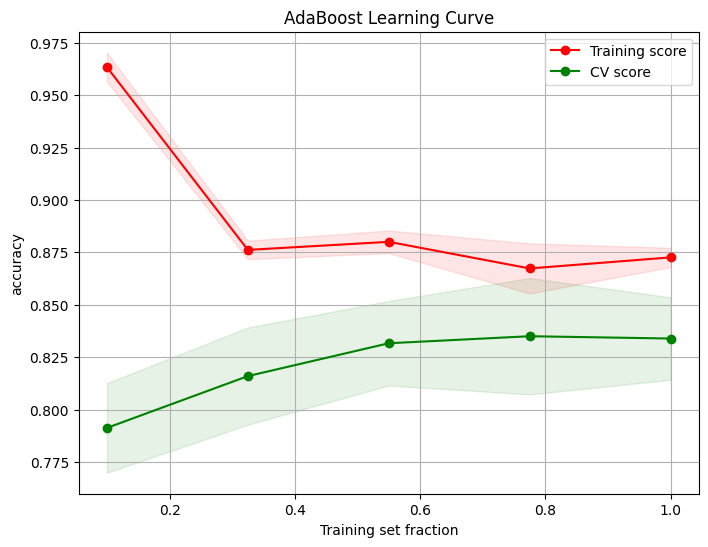

Submission saved!


9268

In [10]:
import optuna
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd
import time
import gc

# -------------------------------
# Optuna objective function for GradientBoosting
# -------------------------------
def objective(trial):
    # Sample hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    max_depth = trial.suggest_int("max_depth", 3, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    criterion = trial.suggest_categorical("criterion", ["friedman_mse", "squared_error"])
    
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        subsample=subsample,
        criterion=criterion,
        random_state=42
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    logloss_scores = []

    for train_idx, valid_idx in skf.split(X_train, y_train_numeric):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

        model.fit(X_tr, y_tr)
        pred_val = model.predict_proba(X_val)[:, 1]  # probabilities for log_loss
        fold_logloss = log_loss(y_val, pred_val)
        logloss_scores.append(fold_logloss)

        # Optional pruning
        trial.report(fold_logloss, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(logloss_scores)

# -------------------------------
# Optuna study setup
# -------------------------------
start = time.time()

sampler = optuna.samplers.TPESampler(n_startup_trials=20, multivariate=True, seed=42)
pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=2, reduction_factor=4)

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=50, timeout=3600)  # adjust trials/time as needed

end = time.time()
print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV log_loss:", study.best_value)

# -------------------------------
# Train final GradientBoosting model with best params
# -------------------------------
best_params = study.best_params

final_model = GradientBoostingClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    subsample=best_params['subsample'],
    criterion=best_params['criterion'],
    random_state=42
)

final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on training set
# -------------------------------
pred_train_proba = final_model.predict_proba(X_train)[:, 1]
pred_train_class = (pred_train_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_train_numeric, pred_train_proba)
logloss = log_loss(y_train_numeric, pred_train_proba)
accuracy = accuracy_score(y_train_numeric, pred_train_class)

print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")


# -------------------------------
# Evaluate on CV set
# -------------------------------

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='roc_auc')
logloss_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='neg_log_loss')
accuracy_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='accuracy')

print("CV ROC-AUC:", np.mean(roc_auc_scores))
print("CV Log Loss:", -np.mean(logloss_scores))
print("CV Accuracy:", np.mean(accuracy_scores))


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
plot_learning_curve(final_model, "GradientBoosting Learning Curve", X_train, y_train_numeric, cv=kfold)


# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test_proba = final_model.predict_proba(X_test)[:, 1]
pred_test_class = (pred_test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_ids,  # replace with your test IDs
    "Survived": pred_test_class
})

submission.to_csv("submission/gradientboost_optuna_submission.csv", index=False)
print("Submission saved!")
gc.collect()


# roc_auc_train = plot_roc(y_train_numeric, pred_train_proba, label='Bagged Tree Train')




[I 2026-02-09 23:52:26,928] A new study created in memory with name: no-name-fffb004c-fc2a-4988-91e7-6d0c24319356
[I 2026-02-09 23:52:30,984] Trial 0 finished with value: 0.4590709780888226 and parameters: {'n_estimators': 341, 'max_samples': 0.9302814174994125, 'max_features': 0.5263979579018735, 'bootstrap': True, 'n_neighbors': 12, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.4590709780888226.
[I 2026-02-09 23:52:34,722] Trial 1 finished with value: 0.4385871439822667 and parameters: {'n_estimators': 308, 'max_samples': 0.8010304804809639, 'max_features': 0.6402448393254869, 'bootstrap': True, 'n_neighbors': 11, 'weights': 'distance', 'p': 1}. Best is trial 1 with value: 0.4385871439822667.
[I 2026-02-09 23:52:39,022] Trial 2 finished with value: 0.4860439270593341 and parameters: {'n_estimators': 383, 'max_samples': 0.5362816821358117, 'max_features': 0.9046188144491041, 'bootstrap': False, 'n_neighbors': 7, 'weights': 'distance', 'p': 2}. Best is trial 1 with value

Optuna finished in 156.45 seconds
Best params: {'n_estimators': 128, 'max_samples': 0.8485329486920079, 'max_features': 0.5206761324365132, 'bootstrap': True, 'n_neighbors': 6, 'weights': 'distance', 'p': 1}
Best CV log_loss: 0.42359929564776594
Train ROC AUC: 0.94803
Train Log Loss: 0.30599
Train Accuracy: 0.90460
CV ROC-AUC: 0.8726848958388883
CV Log Loss: 0.42359929564776594
CV Accuracy: 0.8204067541271733


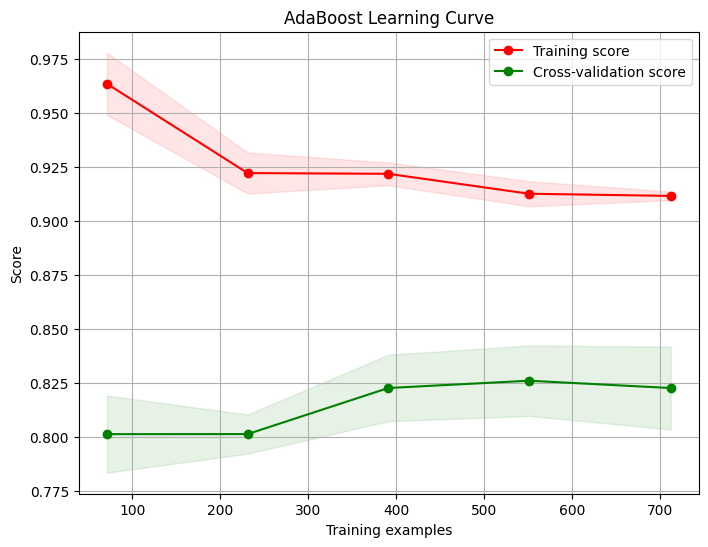

Submission saved!


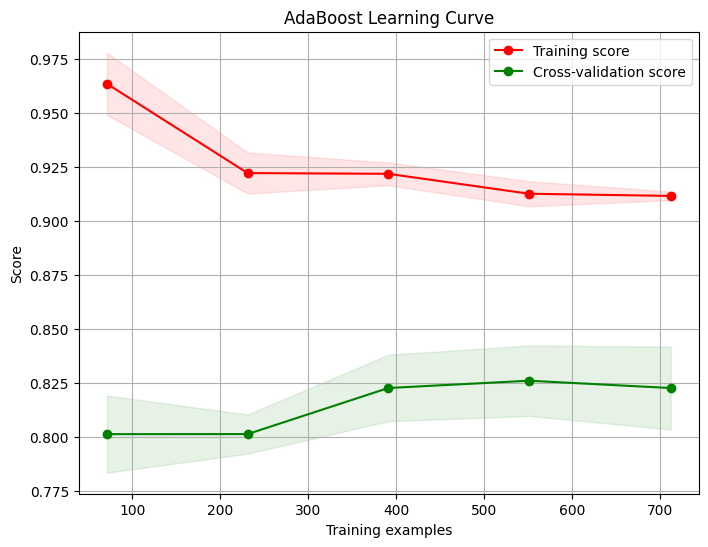

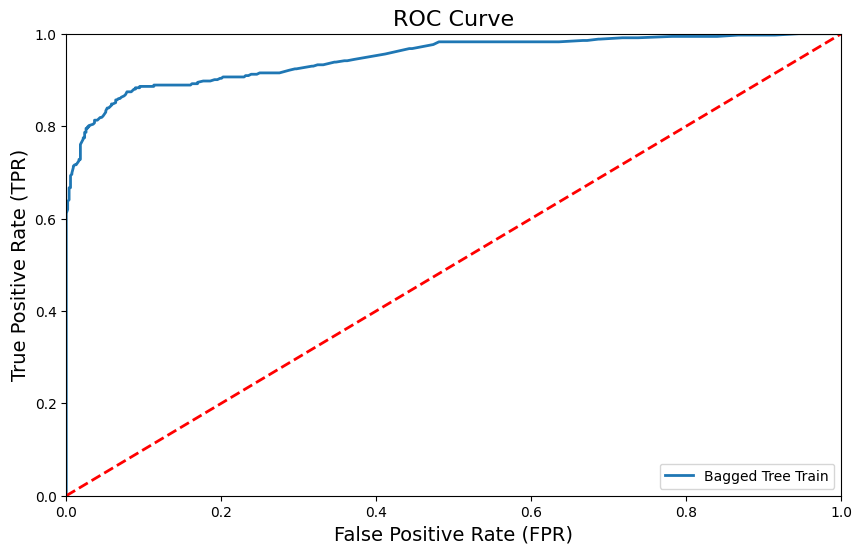

ROC-AUC Score: 0.94803


In [ ]:
import optuna
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd
import time
import gc

# -------------------------------
# Optuna objective function for Bagging + KNN
# -------------------------------
def objective(trial):
    # Bagging hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 700)
    max_samples = trial.suggest_float("max_samples", 0.5, 1.0)
    max_features = trial.suggest_float("max_features", 0.5, 1.0)
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])

    # Base KNN hyperparameters
    n_neighbors = trial.suggest_int("n_neighbors", 3, 20)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_int("p", 1, 2)  # 1=Manhattan, 2=Euclidean

    base_estimator = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        n_jobs=-1
    )

    model = BaggingClassifier(
        estimator=base_estimator,
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        bootstrap=bootstrap,
        n_jobs=-1,
        random_state=42
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    logloss_scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train_numeric)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[valid_idx]

        model.fit(X_tr, y_tr)
        pred_val = model.predict_proba(X_val)[:, 1]
        logloss_scores.append(log_loss(y_val, pred_val))

        trial.report(logloss_scores[-1], step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(logloss_scores)

# -------------------------------
# Optuna study setup
# -------------------------------
start = time.time()

sampler = optuna.samplers.TPESampler(n_startup_trials=20, multivariate=True, seed=42)
pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2, reduction_factor=4, min_early_stopping_rate=1
)

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=50, timeout=3600)

end = time.time()
print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV log_loss:", study.best_value)

# -------------------------------
# Train final Bagging+KNN model with best params
# -------------------------------
best_params = study.best_params

final_base_estimator = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    p=best_params['p'],
    n_jobs=-1
)



final_model = BaggingClassifier(
    estimator=final_base_estimator,
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    bootstrap=best_params['bootstrap'],
    n_jobs=-1,
    random_state=42
)

final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on training set
# -------------------------------
pred_train_proba = final_model.predict_proba(X_train)[:, 1]
pred_train_class = (pred_train_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_train_numeric, pred_train_proba)
logloss = log_loss(y_train_numeric, pred_train_proba)
accuracy = accuracy_score(y_train_numeric, pred_train_class)

print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")

# -------------------------------
# Evaluate on CV set
# -------------------------------

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='roc_auc')
logloss_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='neg_log_loss')
accuracy_scores = cross_val_score(final_model, X_train, y_train_numeric, cv=skf, scoring='accuracy')

print("CV ROC-AUC:", np.mean(roc_auc_scores))
print("CV Log Loss:", -np.mean(logloss_scores))
print("CV Accuracy:", np.mean(accuracy_scores))


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
plot_learning_curve(final_model, "AdaBoost Learning Curve", X_train, y_train_numeric, cv=kfold)
# roc_auc_train = plot_roc(y_train_numeric, pred_train_proba, label='Bagged Tree Train')



# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test_proba = final_model.predict_proba(X_test)[:, 1]
pred_test_class = (pred_test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": pred_test_class
})

submission.to_csv("submission/bagged_knn_optuna_submission.csv", index=False)
print("Submission saved!")
gc.collect()






